# Lab 10

## Word Embeddings

Word Embeddings in NLP is a technique where individual words are represented as real-valued vectors in a lower-dimensional space and captures inter-word semantics.

Each word is represented by a real-valued vector with tens or hundreds of dimensions.

The goal is that words that are similar in meaning end up close to together in this vector space.

In [32]:
# download glove and unzip it in Notebook.
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove*.zip

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn import decomposition
from scipy.spatial import distance
import matplotlib.pyplot as plt

In [34]:
def embedding_for_vocab(filepath, word_index, embedding_dim):

    vocab_size = len(word_index) + 1

    # Adding 1 because of reserved 0 index
    embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim))

    with open(filepath, encoding="utf8") as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim]

    return embedding_matrix_vocab[1:]

In [35]:
# Euclidean distance, and cosine similarity between words
def distances_to_words(word_vec, embedding_matrix, vocab):
  distances = [np.linalg.norm(w - word_vec) for w in embedding_matrix]
  cosines = [distance.cosine(w, word_vec) for w in embedding_matrix]
  return dict(zip(vocab, zip(distances, cosines)))

In [36]:
sentence = 'I hate sentences with words and you love cats and dogs'.split()

# Generate some tokens
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentence)
vocab = list(tokenizer.word_index.keys())

print(vocab)
print(f'Number of unique words: {len(vocab)}')

['and', 'i', 'hate', 'sentences', 'with', 'words', 'you', 'love', 'cats', 'dogs']
Number of unique words: 10


In [37]:
# Get the embedding matrix for our tokens
embedding_dim = 50
embedding_matrix = embedding_for_vocab(
    'glove.6B.50d.txt', tokenizer.word_index,
  embedding_dim)

Here is an example of what a 50-dimensional word embedding for cat looks like

In [38]:
print(f'Embedding for {vocab[8]}:\n{embedding_matrix[8]}')

Embedding for cats:
[ 0.43081999 -0.85215998 -0.55638999 -0.65060002 -0.10458     0.65967
 -0.92106998 -0.74283999  0.3937     -0.038858    0.19050001  0.41126999
  1.01849997 -0.32416001  0.40059999  0.32466999  0.73039001  0.18565001
 -1.59070003  0.043061   -0.69752002  0.23117     0.82313001  0.60308999
  0.36480999 -0.28048    -0.87353998 -0.32552999  0.25027999 -1.11129999
  1.27409995  0.95437998  0.13716     0.14218999  0.23295     0.53823
  0.35135001 -0.56597     0.16353001 -0.63071001 -0.30528    -0.19734
  0.29626     0.99036998  1.09089994  0.52191001 -0.12515    -0.77693999
  0.69387001 -0.10724   ]


For the sake of visualization and also to demonstrate something interesting about distance in higher dimensions we are going to do a PCA reduction to 3 dimensions.

In [39]:
# Use PCA for dimensionality reduction
pca = decomposition.PCA(n_components=3)
pca.fit(embedding_matrix)
transformed_embedding_matrix = pca.transform(embedding_matrix)

print(f'PCA reduction embedding for {vocab[8]}:\n{transformed_embedding_matrix[8]}')

PCA reduction embedding for cats:
[-1.76066963 -3.17027455 -0.16072346]


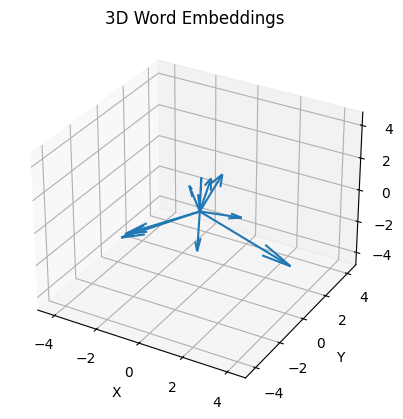

In [40]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

border_size = 0

for word in transformed_embedding_matrix[:]:
  if border_size < np.linalg.norm(word):
    border_size = np.linalg.norm(word)
  ax.quiver(0,0,0, word[0], word[1], word[2])

ax.set_xlim([-border_size, border_size])
ax.set_ylim([-border_size, border_size])
ax.set_zlim([-border_size, border_size])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Word Embeddings')

plt.show()

A common task is to find similar words, we can do this by measuring the distances between vectors.

In [41]:
# Euclidean distance and cosine similarity for cats vs every word in 50 dimensions sorted by euclidean distance
dict(sorted(distances_to_words(embedding_matrix[8], embedding_matrix, vocab).items(), key=lambda item: item[1][0]))

{'cats': (np.float64(0.0), np.float64(0.0)),
 'dogs': (np.float64(2.5699367732856775), np.float64(0.14834811568204442)),
 'and': (np.float64(5.0242282830988), np.float64(0.6056605853475896)),
 'hate': (np.float64(5.148447912541243), np.float64(0.6042891754239641)),
 'love': (np.float64(5.21529340491982), np.float64(0.5612781983560892)),
 'with': (np.float64(5.4123908395493325), np.float64(0.6914559155544078)),
 'you': (np.float64(5.867163938670823), np.float64(0.5371576328607621)),
 'words': (np.float64(5.988069669006666), np.float64(0.753404570487305)),
 'i': (np.float64(6.069612950513695), np.float64(0.60396692071035)),
 'sentences': (np.float64(7.126885574919862), np.float64(0.990043853388019))}

In [42]:
# Euclidean distance and cosine distance for cats vs every word in 50 dimensions sorted by cosine distance
dict(sorted(distances_to_words(embedding_matrix[8], embedding_matrix, vocab).items(), key=lambda item: item[1][1]))

{'cats': (np.float64(0.0), np.float64(0.0)),
 'dogs': (np.float64(2.5699367732856775), np.float64(0.14834811568204442)),
 'you': (np.float64(5.867163938670823), np.float64(0.5371576328607621)),
 'love': (np.float64(5.21529340491982), np.float64(0.5612781983560892)),
 'i': (np.float64(6.069612950513695), np.float64(0.60396692071035)),
 'hate': (np.float64(5.148447912541243), np.float64(0.6042891754239641)),
 'and': (np.float64(5.0242282830988), np.float64(0.6056605853475896)),
 'with': (np.float64(5.4123908395493325), np.float64(0.6914559155544078)),
 'words': (np.float64(5.988069669006666), np.float64(0.753404570487305)),
 'sentences': (np.float64(7.126885574919862), np.float64(0.990043853388019))}

In [43]:
# Euclidean distance and cosine distance for cats vs every word in 3 dimensions sorted by euclidean distance
dict(sorted(distances_to_words(transformed_embedding_matrix[8], transformed_embedding_matrix, vocab).items(), key=lambda item: item[1][0]))

{'cats': (np.float64(0.0), np.float64(0.0)),
 'dogs': (np.float64(0.26678161666868466), np.float64(0.0006761809478051939)),
 'hate': (np.float64(4.114227866906136), np.float64(0.8862225559828101)),
 'love': (np.float64(4.509453474381105), np.float64(1.4807644034460044)),
 'and': (np.float64(4.594723031212092), np.float64(1.0892167697133037)),
 'with': (np.float64(5.062298280214201), np.float64(1.2759005475225422)),
 'you': (np.float64(5.3471815714109905), np.float64(1.3596813083373045)),
 'words': (np.float64(5.399084283871887), np.float64(1.8675795108106954)),
 'i': (np.float64(5.679237008126342), np.float64(1.5317108469907628)),
 'sentences': (np.float64(6.830321966832693), np.float64(1.2965808667742649))}

In [44]:
# Euclidean distance and cosine distance for cats vs every word in 3 dimensions sorted by cosine distance
dict(sorted(distances_to_words(transformed_embedding_matrix[8], transformed_embedding_matrix, vocab).items(), key=lambda item: item[1][1]))

{'cats': (np.float64(0.0), np.float64(0.0)),
 'dogs': (np.float64(0.26678161666868466), np.float64(0.0006761809478051939)),
 'hate': (np.float64(4.114227866906136), np.float64(0.8862225559828101)),
 'and': (np.float64(4.594723031212092), np.float64(1.0892167697133037)),
 'with': (np.float64(5.062298280214201), np.float64(1.2759005475225422)),
 'sentences': (np.float64(6.830321966832693), np.float64(1.2965808667742649)),
 'you': (np.float64(5.3471815714109905), np.float64(1.3596813083373045)),
 'love': (np.float64(4.509453474381105), np.float64(1.4807644034460044)),
 'i': (np.float64(5.679237008126342), np.float64(1.5317108469907628)),
 'words': (np.float64(5.399084283871887), np.float64(1.8675795108106954))}

Euclidean Distance is not as useful when the dimensionality of the data is high, we generally want to opt for cosine similarity.

In [45]:
print(f'{vocab[8]} vs dogs')
dim_50_distances = dict(sorted(distances_to_words(embedding_matrix[8], embedding_matrix, vocab).items(), key=lambda item: item[1][0]))
print(dim_50_distances['dogs'])
print()

print(f'{vocab[1]} vs you')
dim_50_distances = dict(sorted(distances_to_words(embedding_matrix[1], embedding_matrix, vocab).items(), key=lambda item: item[1][0]))
print(dim_50_distances['you'])

cats vs dogs
(np.float64(2.5699367732856775), np.float64(0.14834811568204442))

i vs you
(np.float64(2.4741818418422676), np.float64(0.07627084980270094))


# Student Section

Get the embedding for a set of words of your choosing and see if you can demonstrate that a concept has been encoded in the vector space.

If you cannot think of one try the set of words [female, male, woman, man, aunt, uncle, queen, king, actress, actor, goddess, god] and see if you can find a vector representing binary gender.

Print this vector and include a short description of what you think it conveys.

See how it compares to the actual embeddings to provide some evidence.

As an example:

$E(aunt) - E(uncle) ≈ E(woman) - E(man)$

So the direction denoting gender might be approximately represented $ E(woman) - E(man)$ in our vector space.

In [46]:
sentence = 'aunt uncle woman man'.split()
# Generate your tokens
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentence)
vocab = list(tokenizer.word_index.keys())

# Print your tokens and the number of unique words
print(vocab)
print(f'Number of unique words: {len(vocab)}')

['aunt', 'uncle', 'woman', 'man']
Number of unique words: 4


In [47]:
# Get the embedding matrix for your tokens
embedding_dim = 50
embedding_matrix = embedding_for_vocab(
    'glove.6B.50d.txt', tokenizer.word_index,
  embedding_dim)

In [48]:
# Print the words and the embedding of the words you will use to compute your vector (Note that doing an average may be more precise)
print(f'Embedding for {vocab[3]}:\n{embedding_matrix[3]}')

Embedding for man:
[-0.094386    0.43007001 -0.17224    -0.45528999  1.64470005  0.40335
 -0.37263     0.25071001 -0.10588     0.10778    -0.10848     0.15181001
 -0.65395999  0.55053997  0.59591001 -0.46278     0.11847     0.64447999
 -0.70947999  0.23947001 -0.82905     1.27199996  0.033021    0.29350001
  0.39109999 -2.80940008 -0.70744997  0.41060001  0.38940001 -0.2913
  2.61240005 -0.34575999 -0.16832     0.25154001  0.31215999  0.31639001
  0.12538999 -0.012646    0.22296999 -0.56585002 -0.086264    0.62549001
 -0.0576      0.29374999  0.66004997 -0.53114998 -0.48232999 -0.97925001
  0.53135002 -0.11725   ]


In [49]:
# Print the difference between your vectors and write what it represents in the text field below.

# aunt - uncle ~= woman - man
dict(sorted(distances_to_words(transformed_embedding_matrix[0], transformed_embedding_matrix, vocab).items(), key=lambda item: item[1][0]))

{'aunt': (np.float64(0.0), np.float64(0.0)),
 'uncle': (np.float64(4.167215132607686), np.float64(1.207302118066806)),
 'woman': (np.float64(4.849144152781), np.float64(1.9548539071490991)),
 'man': (np.float64(5.250521629680484), np.float64(0.9228546527786774))}

In [50]:
dict(sorted(distances_to_words(transformed_embedding_matrix[2], transformed_embedding_matrix, vocab).items(), key=lambda item: item[1][0]))

{'woman': (np.float64(0.0), np.float64(0.0)),
 'uncle': (np.float64(3.8201166422462234), np.float64(1.056644888685327)),
 'aunt': (np.float64(4.849144152781), np.float64(1.9548539071490991)),
 'man': (np.float64(4.924217135457055), np.float64(0.8000298574829323))}

My vector represents:

In [51]:
# Provide evidence that your vector does what you say (can just be one example)
# aunt - uncle = (4.17, 1.2)
# woman - man = (4.9, 0.8)

aunt_uncle = np.array([4.17, 1.2])
woman_man = np.array([4.9, 0.8])

euclidean_dist = np.linalg.norm(aunt_uncle - woman_man)
cosine_sim = np.dot(aunt_uncle, woman_man) / (np.linalg.norm(aunt_uncle) * np.linalg.norm(woman_man))

print(f"Euclidean distance: {euclidean_dist:.4f}")
print(f"Cosine similarity: {cosine_sim:.4f}")

# cosine and euclidean show a high euclidean correlation between the two differences, indicating a vector of gender.

Euclidean distance: 0.8324
Cosine similarity: 0.9930
